# 220119 F2 run11: Behavior Decoding Integrations

Integration notebook for the strict behavior-methodology expansion. It keeps the older chained descriptive analysis available, but defaults to the leakage-safe `run_dataset_evaluation` path and verifies every strict output required by the new implementation.

The strict section computes trace preservation, behavior decoding, target-sensitivity variants, block and circular null controls, causal dynamics, causal-sufficiency diagnostics, pseudo-artifact probes, leakage audits, BPI ablations, temporal diagnostics, and cluster-stability artifacts under `outputs/evaluation/v2a-RSNs/<data_name>/`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
print(f"Project root: {PROJECT_ROOT}")


import json

from ica_denoising.behavior_decoding import (
    TraceVariant,
    load_trace_variants,
    make_behavior_targets,
    plot_behavior_preservation_summary,
    plot_behavior_trace_evidence,
    run_decoding_experiment,
    summarize_trace_preservation,
)
from ica_denoising.bss_notebook import (
    BSS_METHODS,
    available_datasets,
    cleaned_trace_output_paths,
    cluster_selection_output_path,
    get_dataset,
    load_traces,
    output_directory,
)
from ica_denoising.causal_behavior_decoding import CausalStateConfig, fit_causal_state_model
from ica_denoising.evaluation_diagnostics import build_provenance_manifest
from ica_denoising.evaluation_runner import load_evaluation_config, run_dataset_evaluation


Project root: /Users/sadiqadedayo/Documents/projects/ICA/ica-denoising


## Configuration

`RUN_CHAINED_BEHAVIOR_DECODING` is on by default so the integration notebook mirrors `behavior_decoding.ipynb`: it runs the descriptive behavior analyses across raw traces and every available cleaned keep-top variant from `cluster_clean_reconstruct.ipynb`. `RUN_STRICT_EVALUATION` also runs the fold-local evaluator and remains the primary leakage-safe path for the methodology expansion.


In [2]:
DATASET_KEY = "v2a-RSNs/220119_F2_run11_fluorescence"
METHODS_TO_RUN = list(BSS_METHODS)

# Keep the chained descriptive behavior analyses on so this notebook mirrors
# behavior_decoding.ipynb across all available cleaned keep-top variants.
RUN_CHAINED_BEHAVIOR_DECODING = True
RUN_STRICT_EVALUATION = True
STRICT_CONFIG_NAME = "evaluation.example.json"  # use evaluation.smoke.json for quick checks
STRICT_FORCE_RECOMPUTE = True

# Set to a tuple/list of frame indices for curated artifact events. The default
# "auto" selects high-amplitude, well-separated trace transients so the artifact
# probe table is populated during integration runs.
ARTIFACT_PROBE_CENTERS = "auto"
N_AUTO_ARTIFACT_PROBES = 12
ARTIFACT_PROBE_MIN_SEPARATION_FRAMES = 30
ARTIFACT_PROBE_EDGE_MARGIN_FRAMES = 10

BOUT_QUANTILE = 0.75
SMOOTH_WINDOW = 3
DECODER_LAGS = (0, 1, 2)
TARGET_SHIFT = 0
BEHAVIOR_N_SPLITS = 5
BEHAVIOR_GAP = 3
RIDGE_ALPHA = 10.0
NULL_BLOCK_SIZE = 60
RANDOM_STATE = 0
N_JOBS = 1

CAUSAL_WINDOW = 15
CAUSAL_TARGET_SHIFTS = (0,)
CAUSAL_LATENT_DIM = 3
CAUSAL_N_SPLITS = 5
CAUSAL_GAP = 14  # must be at least CAUSAL_WINDOW - 1
CAUSAL_RIDGE_ALPHA = 5.0

PLOT_DPI = 300

dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
OUTPUT_DATA_NAME = dataset.recording_id or dataset.data_name
CHAINED_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "behavior_decoding" / dataset.group / OUTPUT_DATA_NAME
CHAINED_FIGURE_DIR = CHAINED_OUTPUT_DIR / "figures"
STRICT_OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "evaluation"
STRICT_OUTPUT_DIR = STRICT_OUTPUT_ROOT / dataset.group / OUTPUT_DATA_NAME

print(f"Dataset: {dataset.key}")
print(f"Trace file: {dataset.trace_path.relative_to(PROJECT_ROOT)}")
print(f"Tail-angle file: {dataset.tail_angle_path.relative_to(PROJECT_ROOT) if dataset.tail_angle_path else None}")
print(f"Chained behavior output: {CHAINED_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"Strict evaluation output: {STRICT_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
build_provenance_manifest([dataset])


Dataset: v2a-RSNs/220119_F2_run11_fluorescence
Trace file: data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluorescence_signals.npy
Tail-angle file: data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_tail_angle.npy
Chained behavior output: outputs/behavior_decoding/v2a-RSNs/220119_F2_run11
Strict evaluation output: outputs/evaluation/v2a-RSNs/220119_F2_run11


,dataset_key,recording_id,fish_id,run_id,modality,sample_rate_hz,trace_path,trace_exists,trace_sha256,trace_shape,...,trace_nonfinite_count,behavior_path,behavior_exists,behavior_sha256,behavior_shape,behavior_dtype,behavior_nonfinite_count,trace_duplicate_count,behavior_duplicate_count,provenance_warning
0,v2a-RSNs/220119_F2_run11_fluorescence,220119_F2_run11,220119_F2,run11,fluorescence,6.0268,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluo...,True,5bf42847c35a9866e4a6e145115b807bf0f40cc662523d8cbf58882a4f74f582,"[1010, 3613]",...,12120,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_tail_angle...,True,9dac573aa4ca2fdfa17ca44a819f47be093a5c2cb94b8a0bfc43b7b2ea14f974,[179876],float64,0,1,1,


## Load Cluster-Cleaned Outputs

This cell is the explicit dependency on `cluster_clean_reconstruct.ipynb`. It requires the cleaned trace and cluster-selection JSON for each selected method.

In [3]:
def _relative(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def load_cluster_stage_inputs(dataset, methods):
    rows = []
    missing = []
    for method in methods:
        method_output_dir = output_directory(
            method,
            OUTPUT_DATA_NAME,
            PROJECT_ROOT,
            analysis_kind="linear",
            dataset_group=dataset.group,
        )
        cleaned_path = cleaned_trace_output_paths(dataset, method, method_output_dir)["cleaned"]
        selection_path = cluster_selection_output_path(dataset, method, method_output_dir)
        if not cleaned_path.exists() or not selection_path.exists():
            missing.append(
                {
                    "method": method,
                    "cleaned_exists": cleaned_path.exists(),
                    "selection_exists": selection_path.exists(),
                    "cleaned_path": _relative(cleaned_path),
                    "selection_path": _relative(selection_path),
                }
            )
            continue
        payload = json.loads(selection_path.read_text(encoding="utf-8"))
        rows.append(
            {
                "method": method,
                "cleaned_path": cleaned_path,
                "cluster_selection_path": selection_path,
                "accepted_clusters": payload.get("accepted_clusters", []),
                "rejected_clusters": payload.get("rejected_clusters", []),
                "accepted_components": payload.get("accepted_components", []),
                "rejected_components": payload.get("rejected_components", []),
                "keep_top_cluster_count": payload.get("keep_top_cluster_count"),
                "selection_scope": payload.get("selection_scope"),
                "n_clusters_observed": payload.get("n_clusters_observed"),
            }
        )
    if not rows:
        missing_table = pd.DataFrame(missing)
        raise FileNotFoundError(
            "No cluster-cleaned outputs were found. Run cluster_clean_reconstruct.ipynb first.\n"
            f"Missing outputs:\n{missing_table.to_string(index=False)}"
        )
    return pd.DataFrame(rows), pd.DataFrame(missing)


cluster_inputs, missing_cluster_inputs = load_cluster_stage_inputs(dataset, METHODS_TO_RUN)
if not missing_cluster_inputs.empty:
    display(missing_cluster_inputs)

cluster_inputs_display = cluster_inputs.copy()
for column in ["cleaned_path", "cluster_selection_path"]:
    cluster_inputs_display[column] = cluster_inputs_display[column].map(_relative)
cluster_inputs_display


,method,cleaned_path,cluster_selection_path,accepted_clusters,rejected_clusters,accepted_components,rejected_components,keep_top_cluster_count,selection_scope,n_clusters_observed
0,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None
1,infomax,outputs/linear/v2a-RSNs/220119_F2_run11/infomax/cleaned/cleaned_infomax_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/infomax/clusters/cluster_selection_infomax_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None
2,sobi,outputs/linear/v2a-RSNs/220119_F2_run11/sobi/cleaned/cleaned_sobi_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/sobi/clusters/cluster_selection_sobi_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None
3,jade,outputs/linear/v2a-RSNs/220119_F2_run11/jade/cleaned/cleaned_jade_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/jade/clusters/cluster_selection_jade_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None


In [4]:
all_variants = load_trace_variants(
    dataset.trace_path.parent,
    raw_name=dataset.trace_path.name,
    cleaned_root=cluster_inputs["cleaned_path"].iloc[0].parents[2],
    dataset_name=dataset.data_name,
    method_glob="*",
    raw_traces=traces.T,
)
raw_variant = next((variant for variant in all_variants if variant.name == "raw"), None)
if raw_variant is None:
    raise ValueError("Raw trace variant was not loaded.")

INCREMENTAL_SELECTION_PREFIX = "keep_top_"
PREFER_INCREMENTAL_VARIANTS = True
methods_to_include = set(METHODS_TO_RUN)
cleaned_variants = [
    variant
    for variant in all_variants
    if variant.name != "raw" and variant.name.split("/", 1)[0] in methods_to_include
]

if PREFER_INCREMENTAL_VARIANTS:
    by_method = {}
    for variant in cleaned_variants:
        method_name = variant.name.split("/", 1)[0]
        by_method.setdefault(method_name, []).append(variant)

    preferred = []
    for method_name in METHODS_TO_RUN:
        method_variants = by_method.get(method_name, [])
        incremental = [
            variant
            for variant in method_variants
            if f"/{INCREMENTAL_SELECTION_PREFIX}" in variant.name
        ]
        preferred.extend(incremental if incremental else method_variants)
    cleaned_variants = preferred


def _selection_id_from_variant(name: str) -> str | None:
    parts = name.split("/")
    if len(parts) >= 3 and parts[1].startswith(INCREMENTAL_SELECTION_PREFIX):
        return parts[1]
    return None


def _clusters_kept_from_selection(selection_id: str | None) -> float:
    if not isinstance(selection_id, str) or not selection_id:
        return np.nan
    return pd.to_numeric(
        selection_id.replace(INCREMENTAL_SELECTION_PREFIX, ""),
        errors="coerce",
    )


def _variant_sort_key(variant):
    parts = variant.name.split("/")
    method_name = parts[0] if parts else variant.name
    selection_id = _selection_id_from_variant(variant.name)
    clusters_kept = _clusters_kept_from_selection(selection_id)
    clusters_sort = int(clusters_kept) if np.isfinite(clusters_kept) else 10**9
    method_sort = METHODS_TO_RUN.index(method_name) if method_name in METHODS_TO_RUN else 10**6
    return (method_sort, method_name, clusters_sort, variant.name)


cleaned_variants = sorted(cleaned_variants, key=_variant_sort_key)
variants = [TraceVariant("raw", raw_variant.path, raw_variant.traces), *cleaned_variants]
if len(variants) < 2:
    raise ValueError("No cleaned trace variants matched the cluster notebook outputs.")

cluster_meta = cluster_inputs.copy()
cluster_meta["method"] = cluster_meta["method"].astype(str)
cluster_meta["cleaned_path"] = cluster_meta["cleaned_path"].map(_relative)
cluster_meta["cluster_selection_path"] = cluster_meta["cluster_selection_path"].map(_relative)

trace_table = pd.DataFrame(
    {
        "variant": [variant.name for variant in variants],
        "version": [variant.name for variant in variants],
        "path": [_relative(variant.path) for variant in variants],
        "shape_time_by_neurons": [variant.traces.shape for variant in variants],
    }
)
trace_table["method"] = trace_table["variant"].map(
    lambda name: "raw" if name == "raw" else name.split("/", 1)[0]
)
trace_table["selection_id"] = trace_table["variant"].map(_selection_id_from_variant)
trace_table["clusters_kept"] = trace_table["selection_id"].map(_clusters_kept_from_selection)
trace_table["is_incremental"] = trace_table["selection_id"].notna()
trace_table = trace_table.merge(
    cluster_meta.add_prefix("cluster_"),
    left_on="method",
    right_on="cluster_method",
    how="left",
)

CHAINED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHAINED_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
trace_table.to_csv(CHAINED_OUTPUT_DIR / "cluster_cleaned_trace_inputs.csv", index=False)
trace_table


,variant,version,path,shape_time_by_neurons,method,selection_id,clusters_kept,is_incremental,cluster_method,cluster_cleaned_path,cluster_cluster_selection_path,cluster_accepted_clusters,cluster_rejected_clusters,cluster_accepted_components,cluster_rejected_components,cluster_keep_top_cluster_count,cluster_selection_scope,cluster_n_clusters_observed
0,raw,raw,data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluorescence_signals.npy,"(3601, 100)",raw,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_01/cleaned/cleaned_fastica_220119_...,"(3601, 100)",fastica,keep_top_01,1.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None
2,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_02/cleaned/cleaned_fastica_220119_...,"(3601, 100)",fastica,keep_top_02,2.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None
3,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_03/cleaned/cleaned_fastica_220119_...,"(3601, 100)",fastica,keep_top_03,3.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None
4,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_04/cleaned/cleaned_fastica_220119_...,"(3601, 100)",fastica,keep_top_04,4.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None
5,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_05/cleaned/cleaned_fastica_220119_...,"(3601, 100)",fastica,keep_top_05,5.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None
6,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_06/cleaned/cleaned_fastica_220119_...,"(3601, 100)",fastica,keep_top_06,6.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,[],[],[],[],None,full_recording_descriptive,None
7,infomax/keep_top_01/cleaned_infomax_22011

## Align Behavior Targets

In [5]:
if dataset.tail_angle_path is None or not dataset.tail_angle_path.exists():
    raise FileNotFoundError(f"{dataset.key} has no available tail-angle file.")

raw = variants[0].traces
tail_angle = np.load(dataset.tail_angle_path, allow_pickle=False)
targets = make_behavior_targets(
    tail_angle,
    n_frames=raw.shape[0],
    bout_quantile=BOUT_QUANTILE,
    smooth_window=SMOOTH_WINDOW,
)

target_summary = pd.Series(
    {
        "tail_samples": tail_angle.shape[0],
        "calcium_frames": raw.shape[0],
        "samples_per_calcium_frame": tail_angle.shape[0] / raw.shape[0],
        "bout_threshold": targets.bout_threshold,
        "bout_fraction": targets.bout_state.mean(),
    }
)
target_summary.to_csv(CHAINED_OUTPUT_DIR / "behavior_target_alignment_summary.csv")
target_summary


tail_samples                 179876.000000
calcium_frames                 3601.000000
samples_per_calcium_frame        49.951680
bout_threshold                    1.037580
bout_fraction                     0.250486
dtype: float64

Saved target alignment plot: outputs/behavior_decoding/v2a-RSNs/220119_F2_run11/figures/tail_behavior_alignment_220119_F2_run11_fluorescence.png


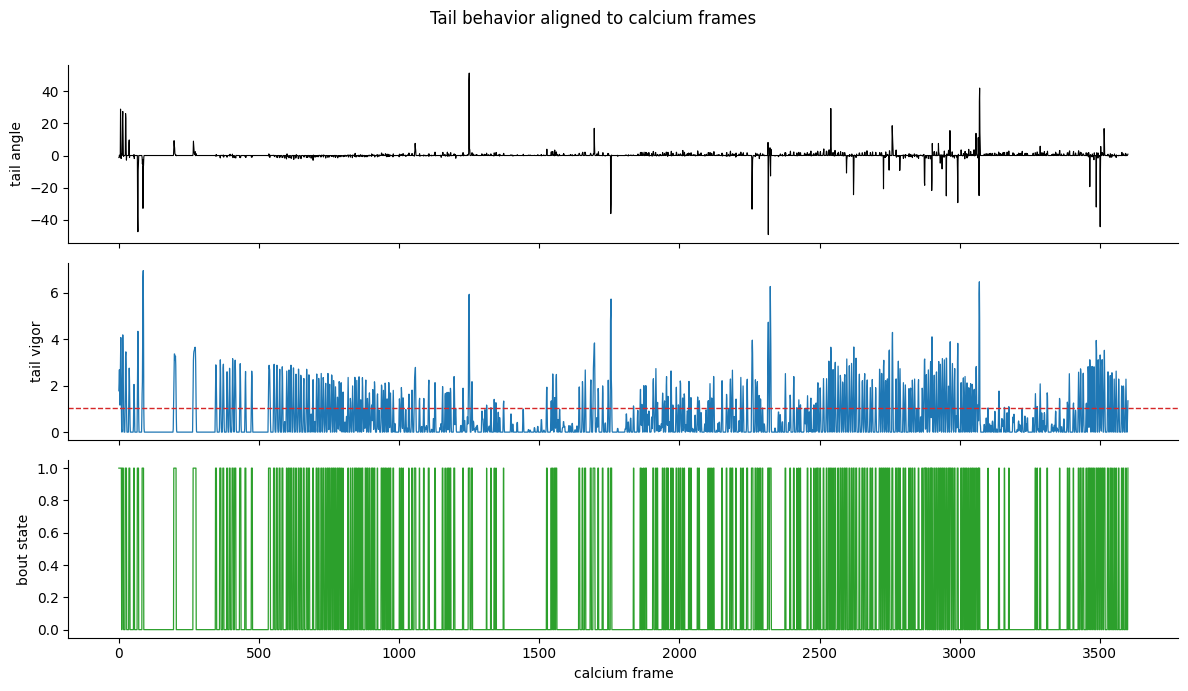

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
frames = np.arange(raw.shape[0])
axes[0].plot(frames, targets.angle, color="black", lw=0.8)
axes[0].set_ylabel("tail angle")
axes[1].plot(frames, targets.vigor, color="tab:blue", lw=0.9)
axes[1].axhline(targets.bout_threshold, color="tab:red", ls="--", lw=1)
axes[1].set_ylabel("tail vigor")
axes[2].plot(frames, targets.bout_state, color="tab:green", lw=0.9)
axes[2].set_ylabel("bout state")
axes[2].set_xlabel("calcium frame")
fig.suptitle("Tail behavior aligned to calcium frames")
fig.tight_layout(rect=(0, 0, 1, 0.97))
target_plot_path = CHAINED_FIGURE_DIR / f"tail_behavior_alignment_{dataset.data_name}.png"
fig.savefig(target_plot_path, dpi=PLOT_DPI, bbox_inches="tight")
print(f"Saved target alignment plot: {target_plot_path.relative_to(PROJECT_ROOT)}")


## Chained Supervised Behavior Decoding

This section decodes behavior from the raw traces and from the cleaned traces produced by `cluster_clean_reconstruct.ipynb`. These outputs are stage-dependent and descriptive.

In [7]:
trace_preservation = summarize_trace_preservation(variants, reference_name="raw")
trace_preservation_path = CHAINED_OUTPUT_DIR / "full_recording_trace_preservation.csv"
trace_preservation.to_csv(trace_preservation_path, index=False)
print(f"Saved trace preservation metrics: {trace_preservation_path.relative_to(PROJECT_ROOT)}")
trace_preservation


Saved trace preservation metrics: outputs/behavior_decoding/v2a-RSNs/220119_F2_run11/full_recording_trace_preservation.csv


,variant,path,reference,n_frames,n_neurons,global_pearson,neuron_pearson_mean,neuron_pearson_median,neuron_pearson_q25,neuron_pearson_q75,rmse_mean,nrmse_mean,mean_abs_delta,variance_ratio_median,variance_ratio_q25,variance_ratio_q75
0,raw,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluo...,raw,3601,100,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
1,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.978418,0.506441,0.522968,0.377310,0.609751,1.053746,0.835733,0.834196,0.273504,0.142381,0.371798
2,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.982613,0.612233,0.618649,0.507541,0.739828,0.949953,0.760747,0.755294,0.382753,0.257626,0.547345
3,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.986020,0.704297,0.705756,0.631616,0.795362,0.853537,0.686162,0.679287,0.498093,0.398961,0.632600
4,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.989737,0.795121,0.795592,0.742686,0.852745,0.730916,0.587746,0.581365,0.632966,0.551583,0.727175
5,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.994073,0.887934,0.892544,0.861766,0.917823,0.554255,0.446125,0.439855,0.796635,0.742653,0.842401
6,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.995964,0.924180,0.924031,0.904479,0.947372,0.458414,0.370236,0.363650,0.853833,0.818082,0.897513
7,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/infomax/cleaned_var...,raw,3601,100,0.983082,0.614206,0.621697,0.527513,0.722097,0.947854,0.763368,0.746744,0.386508,0.278296,0.521429
8,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/infomax/cleaned_var...,raw,3601,100,0.985098,0.647224,0.645251,0.553580,0.757393,0.897319,0.733047,0.710051,0.416355,0.306451,0.573645
9,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/infomax/cleaned_var...,raw,3601,100,0.987829,0.689012,0.704437,0.597669,0.809737,0.815382,0.685352,0.645646,0.496237,0.357220,0.655689


In [8]:
if RUN_CHAINED_BEHAVIOR_DECODING:
    common_kwargs = dict(
        variants=variants,
        lags=DECODER_LAGS,
        target_shift=TARGET_SHIFT,
        n_splits=BEHAVIOR_N_SPLITS,
        gap=BEHAVIOR_GAP,
        ridge_alpha=RIDGE_ALPHA,
        include_transfer=True,
        include_null=True,
        null_block_size=NULL_BLOCK_SIZE,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )
    vigor_result = run_decoding_experiment(
        target=targets.vigor,
        target_name="tail_vigor",
        task="regression",
        **common_kwargs,
    )
    bout_result = run_decoding_experiment(
        target=targets.bout_state,
        target_name="bout_state",
        task="classification",
        **common_kwargs,
    )

    supervised_metrics = pd.concat([vigor_result.metrics, bout_result.metrics], ignore_index=True)
    supervised_summary = pd.concat([vigor_result.summary, bout_result.summary], ignore_index=True)
    supervised_predictions = pd.concat([vigor_result.predictions, bout_result.predictions], ignore_index=True)
else:
    supervised_metrics = pd.DataFrame()
    supervised_summary = pd.DataFrame()
    supervised_predictions = pd.DataFrame()

supervised_summary.head(40)


,target,target_variant,bout_quantile,smooth_window,null_strategy,task,comparison,train_version,test_version,r2_mean,...,rmse_mean,rmse_std,nrmse_mean,nrmse_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std
0,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,-0.019063,...,0.917013,0.036935,1.009465,0.007401,NaN,NaN,NaN,NaN,NaN,NaN
1,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,-0.026630,...,0.920438,0.037981,1.013204,0.007774,NaN,NaN,NaN,NaN,NaN,NaN
2,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,-0.048392,...,0.930063,0.036558,1.023876,0.009365,NaN,NaN,NaN,NaN,NaN,NaN
3,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,-0.077638,...,0.943370,0.048551,1.038063,0.008881,NaN,NaN,NaN,NaN,NaN,NaN
4,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,-0.110693,...,0.957583,0.046898,1.053823,0.013727,NaN,NaN,NaN,NaN,NaN,NaN
5,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,-0.148437,...,0.973535,0.040267,1.071635,0.006747,NaN,NaN,NaN,NaN,NaN,NaN
6,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,-0.015352,...,0.915366,0.038221,1.007613,0.009154,NaN,NaN,NaN,NaN,NaN,NaN
7,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,-0.023929,...,0.919123,0.037326,1.011824,0.013318,NaN,NaN,NaN,NaN,NaN,NaN
8,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,-0.027332,...,0.920931,0.042687,1.013559,0.006234,NaN,NaN,NaN,NaN,NaN,NaN
9,tail_vigor,primary,NaN,NaN,block_shuffle,regression,null_within,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,-0.031771,...,0.922920,0.042944,1.015744,0.006664,NaN,NaN,NaN,NaN,NaN,NaN


,method,tail_vigor_within_pearson,tail_vigor_within_pearson_preservation_pct,tail_vigor_transfer_pearson,tail_vigor_transfer_pearson_preservation_pct,bout_state_within_balanced_accuracy,bout_state_within_balanced_accuracy_preservation_pct,bout_state_transfer_balanced_accuracy,bout_state_transfer_balanced_accuracy_preservation_pct,behavioral_preservation_index,neuron_pearson_median,nrmse_mean,variance_ratio_median,mean_abs_delta,recommendation_label
0,raw,0.596606,100.000000,0.596606,100.000000,0.735893,100.000000,0.735893,100.000000,100.000000,1.000000,0.000000,1.000000,0.000000,raw reference
1,sobi/keep_top_02/cleaned_sobi_220119_F2_run11_fluorescence,0.611091,102.197971,0.612818,102.460015,0.752961,106.767141,0.746987,104.398761,103.955972,0.719036,0.661608,0.517015,0.645780,best preserved
2,sobi/keep_top_03/cleaned_sobi_220119_F2_run11_fluorescence,0.604822,101.246652,0.606105,101.441357,0.747371,104.550787,0.748906,105.159536,103.099583,0.781102,0.586622,0.610123,0.569259,acceptable
3,infomax/keep_top_05/cleaned_infomax_220119_F2_run11_fluorescence,0.611779,102.302371,0.610934,102.174143,0.744858,103.554702,0.744977,103.601701,102.908229,0.846525,0.505817,0.716605,0.451949,acceptable
4,sobi/keep_top_04/cleaned_sobi_220119_F2_run11_fluorescence,0.597697,100.165560,0.599448,100.431206,0.746012,104.011961,0.750183,105.665697,102.568606,0.853521,0.508509,0.728498,0.492465,acceptable
5,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,0.605040,101.279698,0.606009,101.426753,0.750103,105.634153,0.740257,101.730472,102.517769,0.707947,0.672757,0.501198,0.631112,acceptable
6,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,0.591592,99.239258,0.596937,100.050247,0.750177,105.663364,0.744718,103.498944,102.112953,0.645251,0.733047,0.416355,0.710051,acceptable
7,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,0.593583,99.541360,0.600515,100.593135,0.752427,106.555365,0.740246,101.725895,102.103939,0.704437,0.685352,0.496237,0.645646,acceptable
8,infomax/keep_top_06/cleaned_infomax_220119_F2_run11_fluorescence,0.597355,100.113683,0.599326,100.412782,0.742271,102.528825,0.747191,104.479593,101.883721,0.940365,0.361553,0.884286,0.310367,acceptable
9,sobi/keep_top_05/cleaned_sobi_220119_F2_run11_fluorescence,0.599665,100.464188,0.600089,100.528559,0.741620,102.270617,0.742422,102.588860,101.463056,0.916699,0.396830,0.840337,0.384831,acceptable


,target,task,method,selection_id,clusters_kept,score_metric,score,delta_vs_prev,delta_vs_raw,variant
0,bout_state,classification,fastica,keep_top_01,1.0,balanced_accuracy_mean,0.601787,NaN,-0.134105,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence
1,bout_state,classification,fastica,keep_top_02,2.0,balanced_accuracy_mean,0.640965,0.039178,-0.094928,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence
2,bout_state,classification,fastica,keep_top_03,3.0,balanced_accuracy_mean,0.669381,0.028416,-0.066512,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence
3,bout_state,classification,fastica,keep_top_04,4.0,balanced_accuracy_mean,0.694211,0.024830,-0.041682,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence
4,bout_state,classification,fastica,keep_top_05,5.0,balanced_accuracy_mean,0.709646,0.015435,-0.026246,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence
5,bout_state,classification,fastica,keep_top_06,6.0,balanced_accuracy_mean,0.708791,-0.000856,-0.027102,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence
6,bout_state,classification,infomax,keep_top_01,1.0,balanced_accuracy_mean,0.747958,NaN,0.012065,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence
7,bout_state,classification,infomax,keep_top_02,2.0,balanced_accuracy_mean,0.750177,0.002219,0.014284,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence
8,bout_state,classification,infomax,keep_top_03,3.0,balanced_accuracy_mean,0.752427,0.002250,0.016534,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence
9,bout_state,classification,infomax,keep_top_04,4.0,balanced_accuracy_mean,0.750103,-0.002323,0.014210,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence


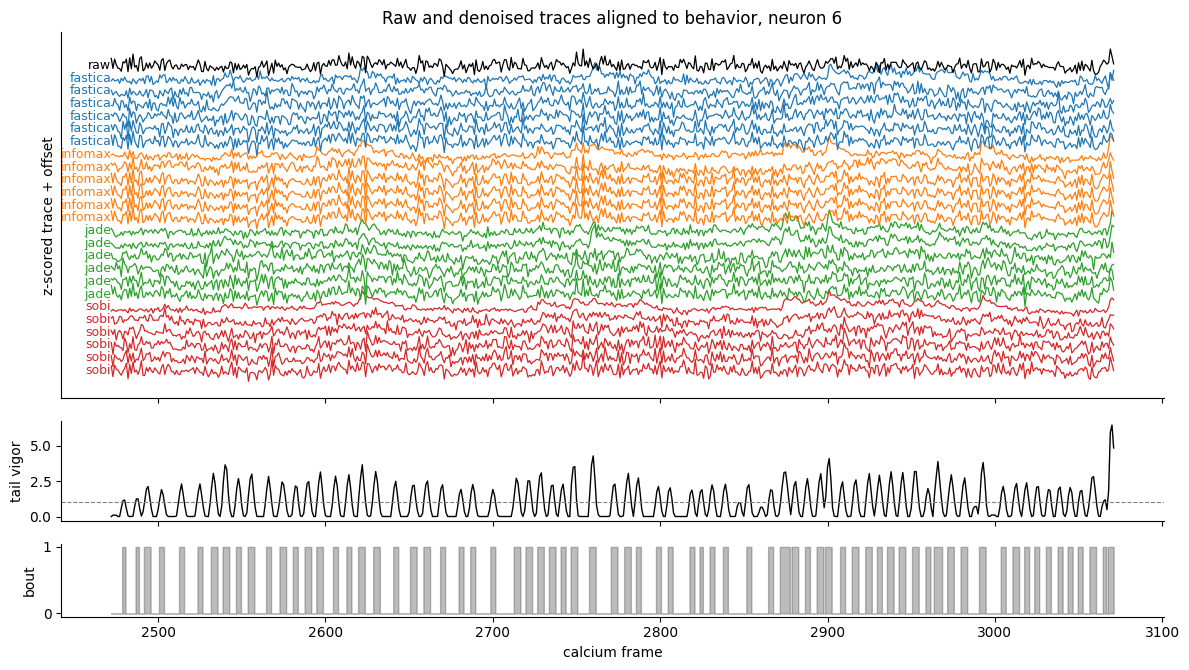

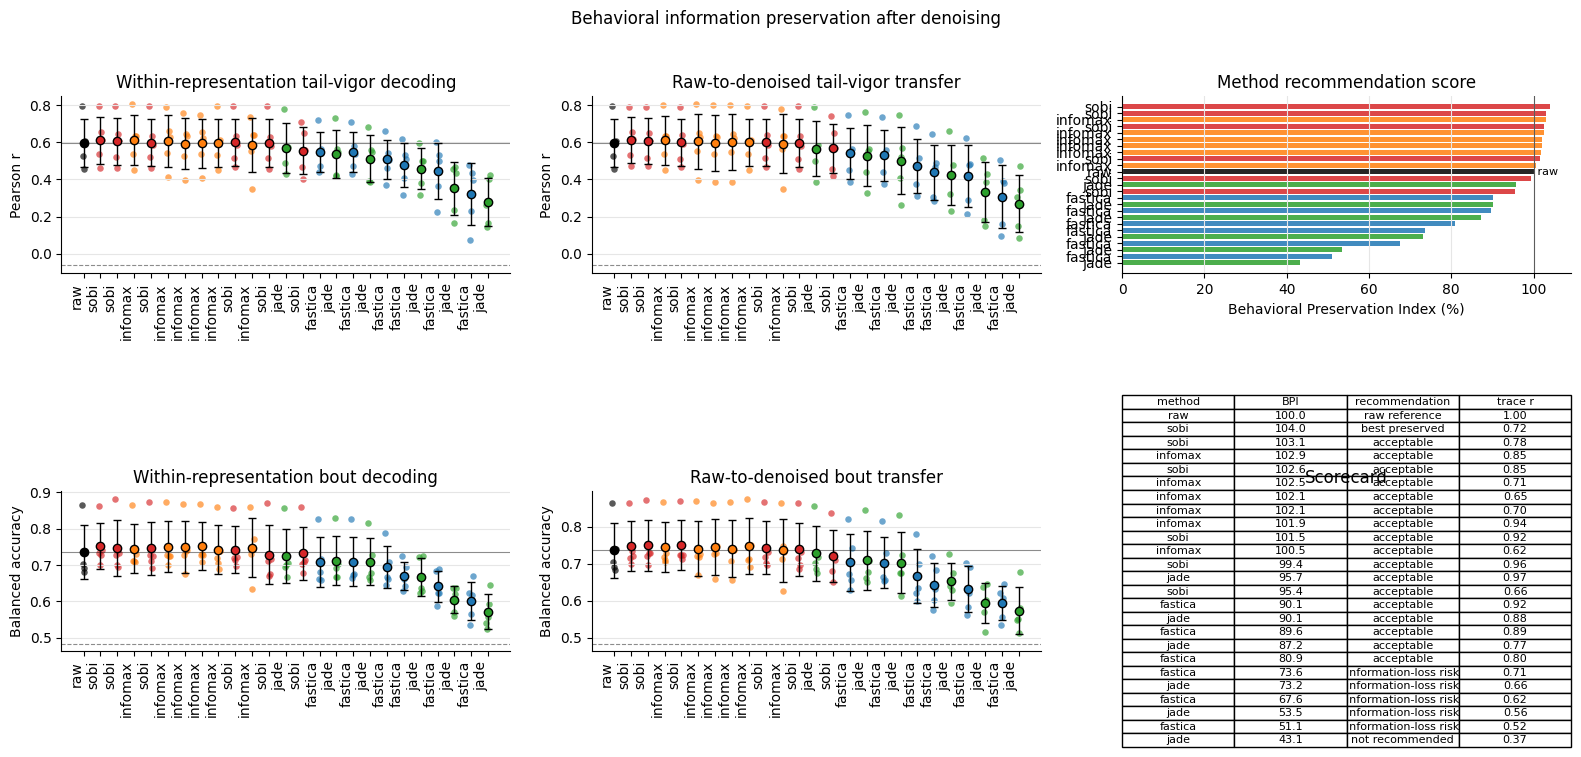

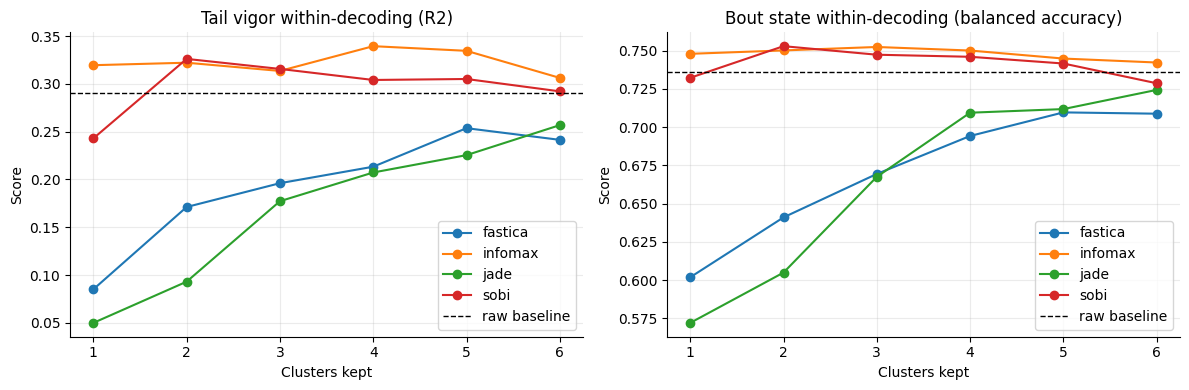

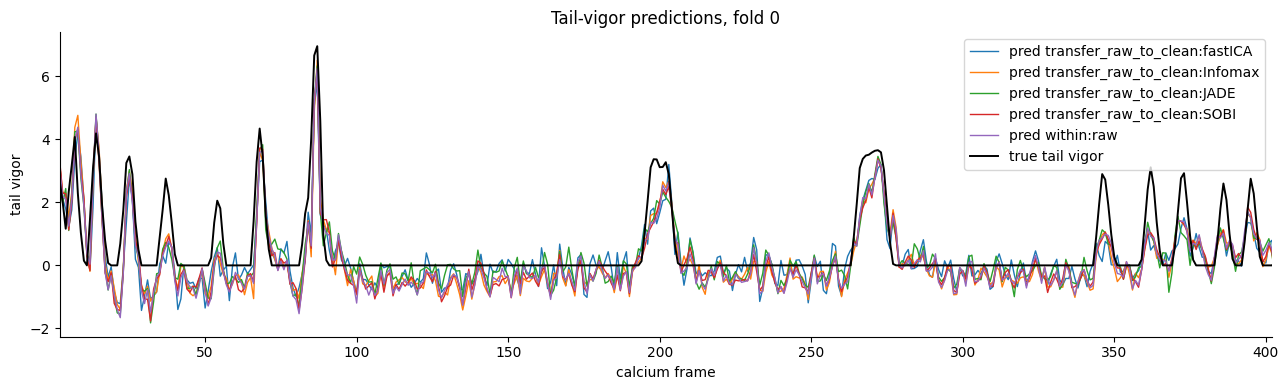

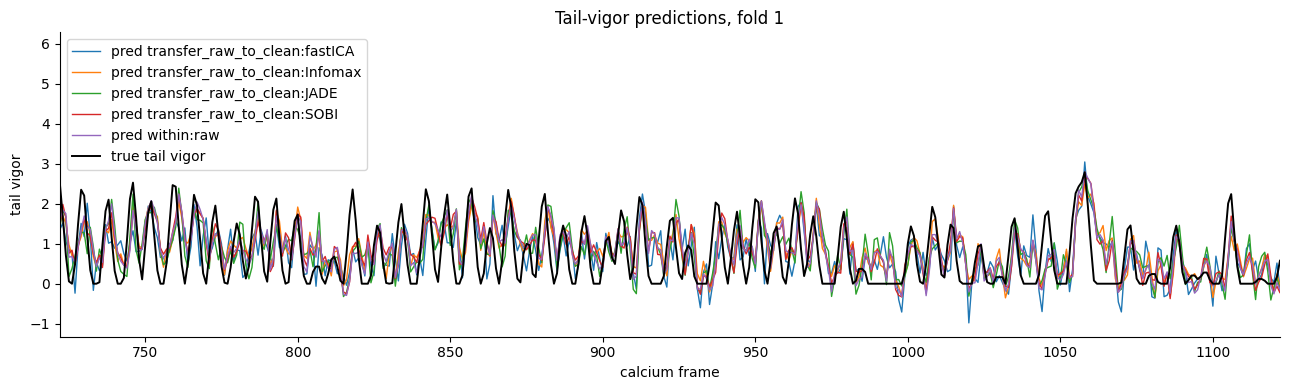

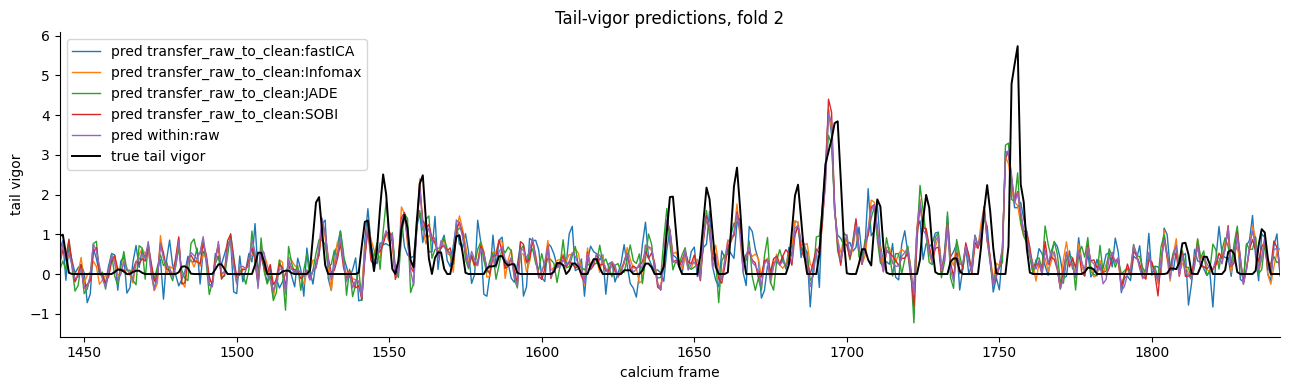

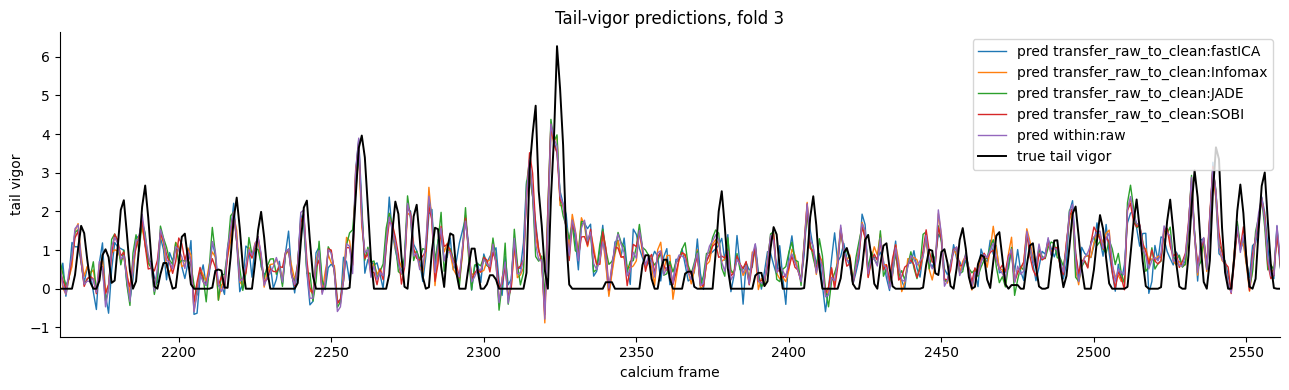

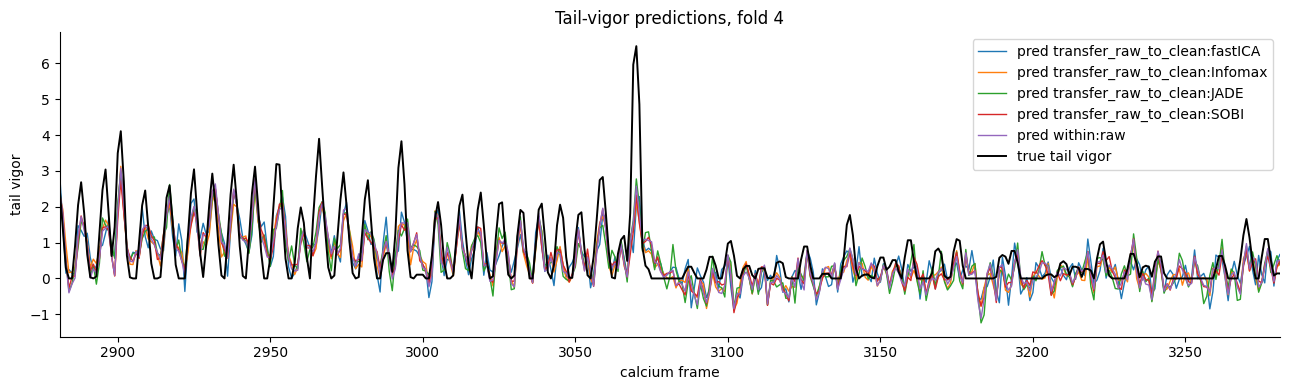

In [9]:
if RUN_CHAINED_BEHAVIOR_DECODING:
    trace_evidence_fig, _ = plot_behavior_trace_evidence(
        variants,
        targets,
        window_size=600,
    )
    preservation_fig, _, behavior_scorecard = plot_behavior_preservation_summary(
        supervised_metrics,
        supervised_summary,
        variants=variants,
    )

    variant_meta = trace_table[["variant", "method", "selection_id", "clusters_kept", "is_incremental"]].copy()
    within_summary = supervised_summary[supervised_summary["comparison"] == "within"].copy().rename(
        columns={"test_version": "variant"}
    )
    within_summary = within_summary.merge(variant_meta, on="variant", how="left")
    within_summary["score"] = np.where(
        within_summary["task"] == "regression",
        within_summary["r2_mean"],
        within_summary["balanced_accuracy_mean"],
    )
    within_summary["score_metric"] = np.where(
        within_summary["task"] == "regression",
        "r2_mean",
        "balanced_accuracy_mean",
    )
    raw_baseline = within_summary[within_summary["variant"] == "raw"][["target", "task", "score"]].rename(
        columns={"score": "raw_score"}
    )

    cluster_progress_table = (
        within_summary[within_summary["is_incremental"]]
        .merge(raw_baseline, on=["target", "task"], how="left")
        .sort_values(["target", "task", "method", "clusters_kept"])
        .copy()
    )
    if not cluster_progress_table.empty:
        cluster_progress_table["delta_vs_prev"] = cluster_progress_table.groupby(
            ["target", "task", "method"]
        )["score"].diff()
        cluster_progress_table["delta_vs_raw"] = cluster_progress_table["score"] - cluster_progress_table["raw_score"]
        cluster_progress_table = cluster_progress_table[
            [
                "target",
                "task",
                "method",
                "selection_id",
                "clusters_kept",
                "score_metric",
                "score",
                "delta_vs_prev",
                "delta_vs_raw",
                "variant",
            ]
        ].reset_index(drop=True)

        progress_plot_targets = [
            ("tail_vigor", "Tail vigor within-decoding (R2)"),
            ("bout_state", "Bout state within-decoding (balanced accuracy)"),
        ]
        cluster_progress_fig, axes = plt.subplots(
            1,
            len(progress_plot_targets),
            figsize=(6 * len(progress_plot_targets), 4),
        )
        axes = np.atleast_1d(axes)
        for ax, (target_name, title) in zip(axes, progress_plot_targets):
            target_rows = cluster_progress_table[cluster_progress_table["target"] == target_name]
            for method_name, group in target_rows.groupby("method"):
                group = group.sort_values("clusters_kept")
                ax.plot(
                    group["clusters_kept"],
                    group["score"],
                    marker="o",
                    lw=1.5,
                    label=method_name,
                )
            task_name = "regression" if target_name == "tail_vigor" else "classification"
            raw_row = raw_baseline[(raw_baseline["target"] == target_name) & (raw_baseline["task"] == task_name)]
            if not raw_row.empty and np.isfinite(raw_row["raw_score"].iloc[0]):
                ax.axhline(
                    raw_row["raw_score"].iloc[0],
                    color="black",
                    linestyle="--",
                    linewidth=1,
                    label="raw baseline",
                )
            if not target_rows.empty:
                ax.set_xticks(sorted(target_rows["clusters_kept"].dropna().astype(int).unique()))
            ax.set_title(title)
            ax.set_xlabel("Clusters kept")
            ax.set_ylabel("Score")
            ax.grid(alpha=0.25)
            ax.legend(loc="best")
        cluster_progress_fig.tight_layout()
    else:
        cluster_progress_fig = None
        print("No incremental keep-top variants detected for supervised behavior progression.")

    prediction_variant_meta = trace_table[
        ["variant", "method", "clusters_kept", "is_incremental"]
    ].copy()
    prediction_variant_meta = prediction_variant_meta[prediction_variant_meta["variant"] != "raw"].copy()
    prediction_variant_meta["is_incremental_sort"] = prediction_variant_meta["is_incremental"].fillna(False).astype(bool)
    prediction_transfer_meta = (
        prediction_variant_meta.sort_values(
            ["method", "is_incremental_sort", "clusters_kept"],
            ascending=[True, True, False],
            na_position="last",
        )
        .groupby("method", as_index=False)
        .head(1)
    )
    prediction_transfer_versions = prediction_transfer_meta["variant"].tolist()
    method_label_map = {
        "fastica": "fastICA",
        "infomax": "Infomax",
        "jade": "JADE",
        "sobi": "SOBI",
    }
    prediction_label_by_version = {
        row.variant: f"pred transfer_raw_to_clean:{method_label_map.get(row.method, row.method)}"
        for row in prediction_transfer_meta.itertuples()
    }
    prediction_trace_figs = []
    prediction_folds = sorted(
        supervised_predictions.loc[
            supervised_predictions["target"] == "tail_vigor", "fold"
        ].dropna().astype(int).unique()
    )
    for fold in prediction_folds:
        prediction_plot_df = supervised_predictions.query(
            "target == 'tail_vigor' and fold == @fold and "
            "((comparison == 'within' and test_version == 'raw') or "
            "(comparison == 'transfer_raw_to_clean' and test_version in @prediction_transfer_versions))"
        ).copy()
        if prediction_plot_df.empty:
            continue
        prediction_trace_fig, ax = plt.subplots(figsize=(13, 4))
        for label, group in prediction_plot_df.groupby(["comparison", "test_version"]):
            group = group.sort_values("time_index")
            plot_label = prediction_label_by_version.get(label[1], f"pred {label[0]}:{label[1]}")
            ax.plot(group["time_index"], group["y_pred"], lw=1, label=plot_label)
        truth = prediction_plot_df.drop_duplicates("time_index").sort_values("time_index")
        ax.plot(truth["time_index"], truth["y_true"], color="black", lw=1.4, label="true tail vigor")
        ax.set_title(f"Tail-vigor predictions, fold {fold}")
        ax.set_xlabel("calcium frame")
        ax.set_ylabel("tail vigor")
        window_start = float(truth["time_index"].min()) if not truth.empty else 0.0
        ax.set_xlim(window_start, window_start + 400)
        ax.legend(loc="best")
        prediction_trace_fig.tight_layout()
        prediction_trace_figs.append((fold, prediction_trace_fig))

    supervised_metrics.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_fold_metrics.csv", index=False)
    supervised_summary.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_summary.csv", index=False)
    supervised_predictions.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_predictions.csv", index=False)
    behavior_scorecard.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_scorecard.csv", index=False)
    behavior_scorecard.to_csv(CHAINED_OUTPUT_DIR / "behavior_preservation_scorecard.csv", index=False)
    if "cluster_progress_table" in globals() and isinstance(cluster_progress_table, pd.DataFrame):
        cluster_progress_table.to_csv(CHAINED_OUTPUT_DIR / "cluster_progression_summary.csv", index=False)
    trace_evidence_fig.savefig(
        CHAINED_FIGURE_DIR / f"full_recording_trace_behavior_evidence_{dataset.data_name}.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    trace_evidence_fig.savefig(
        CHAINED_FIGURE_DIR / "paper_trace_behavior_evidence.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    preservation_fig.savefig(
        CHAINED_FIGURE_DIR / f"full_recording_behavior_preservation_summary_{dataset.data_name}.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    preservation_fig.savefig(
        CHAINED_FIGURE_DIR / "paper_behavior_preservation_summary.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    if cluster_progress_fig is not None:
        cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
        cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "paper_cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
    for fold, prediction_trace_fig in prediction_trace_figs:
        prediction_trace_fig.savefig(
            CHAINED_FIGURE_DIR / f"tail_vigor_prediction_trace_fold_{fold}.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
        if fold == prediction_folds[0]:
            prediction_trace_fig.savefig(
                CHAINED_FIGURE_DIR / "tail_vigor_prediction_trace.png",
                dpi=PLOT_DPI,
                bbox_inches="tight",
            )
    display(behavior_scorecard)
    if "cluster_progress_table" in globals():
        display(cluster_progress_table)


## Chained Causal-State Behavior Decoding

This uses the same raw and cluster-cleaned trace variants loaded above.

In [10]:
if RUN_CHAINED_BEHAVIOR_DECODING:
    causal_config = CausalStateConfig(
        window=CAUSAL_WINDOW,
        target_shifts=CAUSAL_TARGET_SHIFTS,
        latent_dim=CAUSAL_LATENT_DIM,
        n_splits=CAUSAL_N_SPLITS,
        gap=CAUSAL_GAP,
        ridge_alpha=CAUSAL_RIDGE_ALPHA,
        bout_quantile=BOUT_QUANTILE,
        random_state=RANDOM_STATE,
    )
    causal_result = fit_causal_state_model(
        variants=variants,
        targets=targets,
        config=causal_config,
    )
    causal_summary = (
        causal_result.fold_metrics.groupby(["variant", "target_shift"], dropna=False)
        .agg(
            dynamic_mse_normalized_mean=("dynamic_mse_normalized", "mean"),
            dynamic_improvement_vs_persistence_mean=("dynamic_improvement_vs_persistence", "mean"),
            angle_pearson_mean=("angle_pearson", "mean"),
            vigor_pearson_mean=("vigor_pearson", "mean"),
            bout_balanced_accuracy_mean=("bout_balanced_accuracy", "mean"),
        )
        .reset_index()
    )
else:
    causal_result = None
    causal_summary = pd.DataFrame()

causal_summary.head(40)


,variant,target_shift,dynamic_mse_normalized_mean,dynamic_improvement_vs_persistence_mean,angle_pearson_mean,vigor_pearson_mean,bout_balanced_accuracy_mean
0,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,0,0.022805,0.074240,0.077176,0.164752,0.538219
1,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,0,0.012869,0.045205,0.082810,0.215404,0.558212
2,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,0,0.012006,-0.091276,0.103365,0.234213,0.564566
3,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,0,0.011286,0.015819,0.114737,0.224707,0.546613
4,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,0,0.009644,0.011114,0.116121,0.223889,0.562074
5,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,0,0.009077,0.010534,0.114874,0.231094,0.566792
6,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,0,0.007884,0.017921,0.105675,0.255846,0.588341
7,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,0,0.008342,0.011873,0.086534,0.250164,0.580077
8,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,0,0.008359,0.012234,0.091010,0.257644,0.584679
9,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,0,0.008339,0.011125,0.088894,0.260055,0.579852


Saved causal diagnostics plot: outputs/behavior_decoding/v2a-RSNs/220119_F2_run11/figures/full_recording_causal_diagnostics_220119_F2_run11_fluorescence.png


,variant,target_shift,corr_to_angle_next,corr_to_vigor_next,corr_to_bout_next,residual_vigor_corr,residual_bout_corr,variant_label
0,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,0,-0.001664,0.006296,0.004732,0.244832,0.136743,FastICA-k1
1,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,0,-0.004717,0.017682,0.005766,0.297051,0.162773,FastICA-k2
2,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,0,-0.020903,0.030567,0.030998,0.259880,0.152401,FastICA-k3
3,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,0,-0.026885,0.064843,0.051468,0.236183,0.120405,FastICA-k4
4,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,0,-0.001548,0.093403,0.089225,0.264070,0.148103,FastICA-k5
5,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,0,0.005781,0.038496,0.032304,0.265976,0.147247,FastICA-k6
6,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,0,0.004399,-0.006872,-0.006358,0.289943,0.175489,Infomax-k1
7,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,0,0.014043,0.024627,0.012741,0.295572,0.183298,Infomax-k2
8,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,0,0.019782,0.026752,0.013857,0.288227,0.171046,Infomax-k3
9,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,0,0.005940,0.035236,0.024769,0.290745,0.174190,Infomax-k4


,metric,method,selection_id,clusters_kept,target_shift,score,delta_vs_prev,delta_vs_raw,variant
0,bout_balanced_accuracy,fastica,keep_top_01,1.0,0,0.538219,NaN,-0.032660,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence
1,bout_balanced_accuracy,fastica,keep_top_02,2.0,0,0.558212,0.019992,-0.012667,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence
2,bout_balanced_accuracy,fastica,keep_top_03,3.0,0,0.564566,0.006355,-0.006312,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence
3,bout_balanced_accuracy,fastica,keep_top_04,4.0,0,0.546613,-0.017953,-0.024265,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence
4,bout_balanced_accuracy,fastica,keep_top_05,5.0,0,0.562074,0.015460,-0.008805,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence
5,bout_balanced_accuracy,fastica,keep_top_06,6.0,0,0.566792,0.004719,-0.004087,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence
6,bout_balanced_accuracy,infomax,keep_top_01,1.0,0,0.588341,NaN,0.017463,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence
7,bout_balanced_accuracy,infomax,keep_top_02,2.0,0,0.580077,-0.008264,0.009199,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence
8,bout_balanced_accuracy,infomax,keep_top_03,3.0,0,0.584679,0.004601,0.013800,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence
9,bout_balanced_accuracy,infomax,keep_top_04,4.0,0,0.579852,-0.004827,0.008973,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence


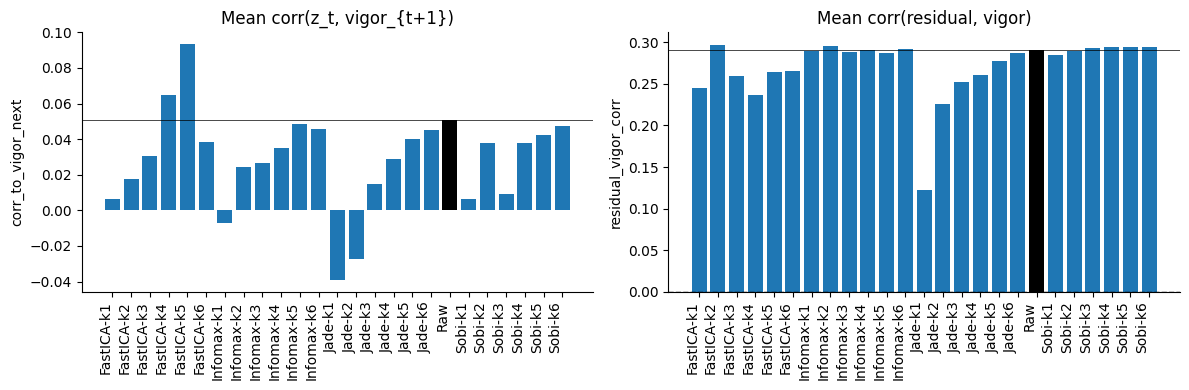

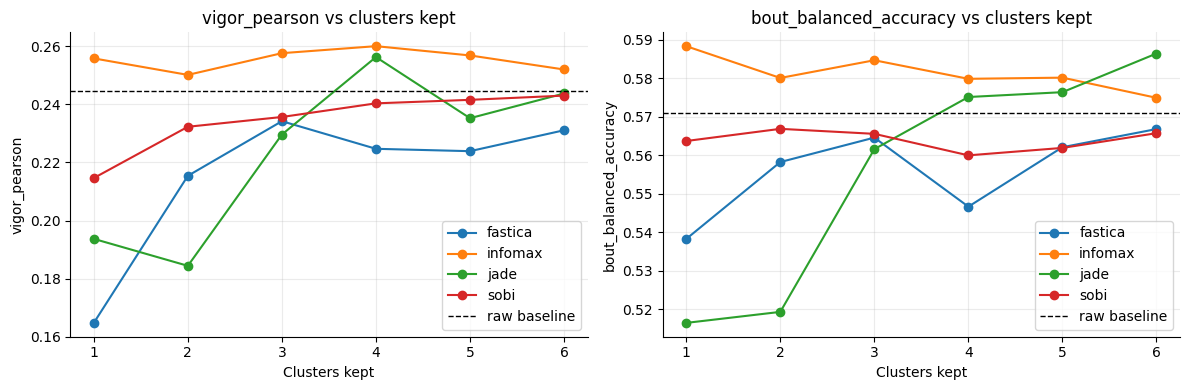

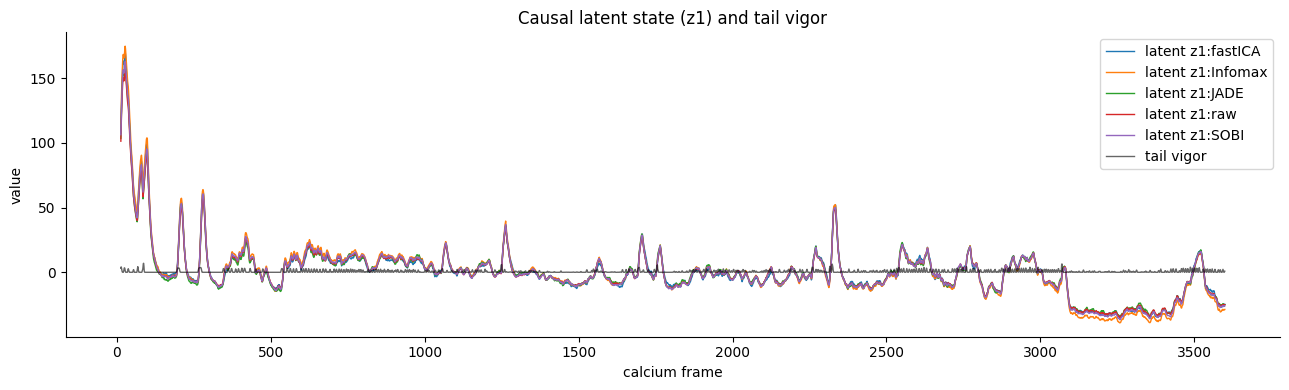

In [14]:
if RUN_CHAINED_BEHAVIOR_DECODING and causal_result is not None:
    causal_result.fold_metrics.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_fold_metrics.csv", index=False)
    causal_summary.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_summary.csv", index=False)
    causal_result.embeddings.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_embeddings.csv", index=False)
    causal_result.graph_metrics.to_csv(
        CHAINED_OUTPUT_DIR / "full_recording_causal_latent_behavior_correlations.csv",
        index=False,
    )
    causal_result.residual_tests.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_residual_tests.csv", index=False)

    graph_summary = causal_result.graph_metrics.groupby(["variant", "target_shift"], as_index=False)[
        ["corr_to_angle_next", "corr_to_vigor_next", "corr_to_bout_next"]
    ].mean()
    resid_summary = causal_result.residual_tests.groupby(["variant", "target_shift"], as_index=False)[
        ["residual_vigor_corr", "residual_bout_corr"]
    ].mean()
    causal_diag = graph_summary.merge(resid_summary, on=["variant", "target_shift"], how="left")

    def _short_variant_label(name: str) -> str:
        if name == "raw":
            return "Raw"
        parts = name.split("/")
        method = parts[0] if parts else name
        method_label = {
            "fastica": "FastICA",
            "infomax": "Infomax",
        }.get(method, method.replace("_", " ").title().replace(" ", ""))
        selection_id = _selection_id_from_variant(name)
        clusters_kept = _clusters_kept_from_selection(selection_id)
        if pd.notna(clusters_kept):
            return f"{method_label}-k{int(clusters_kept)}"
        return method_label

    causal_diag["variant_label"] = causal_diag["variant"].map(_short_variant_label)
    causal_diag.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_diagnostics_summary.csv", index=False)

    causal_diag_fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(causal_diag))
    labels = causal_diag["variant_label"].astype(str).tolist()
    bar_colors = ["black" if variant == "raw" else "tab:blue" for variant in causal_diag["variant"]]
    axes[0].bar(x, causal_diag["corr_to_vigor_next"].to_numpy(dtype=float), color=bar_colors)
    raw_rows = causal_diag[causal_diag["variant"] == "raw"]
    if not raw_rows.empty:
        raw_corr = float(raw_rows.iloc[0]["corr_to_vigor_next"])
        if np.isfinite(raw_corr):
            axes[0].axhline(raw_corr, color="black", linewidth=0.5)
    axes[0].set_title("Mean corr(z_t, vigor_{t+1})")
    axes[0].set_ylabel("corr_to_vigor_next")
    axes[1].bar(x, causal_diag["residual_vigor_corr"].to_numpy(dtype=float), color=bar_colors)
    axes[1].axhline(0.0, linestyle="--", linewidth=1, color="black")
    if not raw_rows.empty:
        raw_resid = float(raw_rows.iloc[0]["residual_vigor_corr"])
        if np.isfinite(raw_resid):
            axes[1].axhline(raw_resid, color="black", linewidth=0.5)
    axes[1].set_title("Mean corr(residual, vigor)")
    axes[1].set_ylabel("residual_vigor_corr")
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90, ha="right")
        ax.set_xlabel("")
    causal_diag_fig.tight_layout()
    causal_diag_plot_path = CHAINED_FIGURE_DIR / f"full_recording_causal_diagnostics_{dataset.data_name}.png"
    causal_diag_fig.savefig(causal_diag_plot_path, dpi=PLOT_DPI, bbox_inches="tight")
    causal_diag_fig.savefig(CHAINED_FIGURE_DIR / "paper_causal_diagnostics_summary.png", dpi=PLOT_DPI, bbox_inches="tight")
    print(f"Saved causal diagnostics plot: {causal_diag_plot_path.relative_to(PROJECT_ROOT)}")

    variant_meta = trace_table[["variant", "method", "selection_id", "clusters_kept", "is_incremental"]].copy()
    causal_summary_with_meta = causal_summary.merge(variant_meta, on="variant", how="left")
    causal_metric_specs = [
        ("vigor_pearson_mean", "vigor_pearson"),
        ("bout_balanced_accuracy_mean", "bout_balanced_accuracy"),
    ]
    progress_frames = []
    for metric_column, metric_name in causal_metric_specs:
        metric_df = causal_summary_with_meta[
            [
                "variant",
                "target_shift",
                "method",
                "selection_id",
                "clusters_kept",
                "is_incremental",
                metric_column,
            ]
        ].copy()
        metric_df = metric_df.rename(columns={metric_column: "score"})
        metric_df["metric"] = metric_name
        raw_scores = metric_df[metric_df["variant"] == "raw"][["target_shift", "score"]].rename(
            columns={"score": "raw_score"}
        )
        metric_df = metric_df[metric_df["is_incremental"]].merge(raw_scores, on="target_shift", how="left")
        progress_frames.append(metric_df)

    causal_cluster_progress = pd.concat(progress_frames, ignore_index=True) if progress_frames else pd.DataFrame()
    if not causal_cluster_progress.empty:
        causal_cluster_progress = causal_cluster_progress.sort_values(
            ["metric", "method", "target_shift", "clusters_kept"]
        )
        causal_cluster_progress["delta_vs_prev"] = causal_cluster_progress.groupby(
            ["metric", "method", "target_shift"]
        )["score"].diff()
        causal_cluster_progress["delta_vs_raw"] = causal_cluster_progress["score"] - causal_cluster_progress["raw_score"]
        causal_cluster_progress = causal_cluster_progress[
            [
                "metric",
                "method",
                "selection_id",
                "clusters_kept",
                "target_shift",
                "score",
                "delta_vs_prev",
                "delta_vs_raw",
                "variant",
            ]
        ].reset_index(drop=True)

        causal_cluster_progress_fig, axes = plt.subplots(
            1,
            len(causal_metric_specs),
            figsize=(6 * len(causal_metric_specs), 4),
        )
        axes = np.atleast_1d(axes)
        baseline_shift = CAUSAL_TARGET_SHIFTS[0] if CAUSAL_TARGET_SHIFTS else 0
        for ax, (metric_column, metric_name) in zip(axes, causal_metric_specs):
            metric_rows = causal_cluster_progress[causal_cluster_progress["metric"] == metric_name]
            for method_name, group in metric_rows.groupby("method"):
                group = group.sort_values("clusters_kept")
                ax.plot(
                    group["clusters_kept"],
                    group["score"],
                    marker="o",
                    lw=1.5,
                    label=method_name,
                )
            baseline_rows = causal_summary_with_meta[
                (causal_summary_with_meta["variant"] == "raw")
                & (causal_summary_with_meta["target_shift"] == baseline_shift)
            ]
            if not baseline_rows.empty:
                baseline_value = baseline_rows.iloc[0][metric_column]
                if np.isfinite(baseline_value):
                    ax.axhline(
                        baseline_value,
                        color="black",
                        linestyle="--",
                        linewidth=1,
                        label="raw baseline",
                    )
            if not metric_rows.empty:
                ax.set_xticks(sorted(metric_rows["clusters_kept"].dropna().astype(int).unique()))
            ax.set_title(f"{metric_name} vs clusters kept")
            ax.set_xlabel("Clusters kept")
            ax.set_ylabel(metric_name)
            ax.grid(alpha=0.25)
            ax.legend(loc="best")
        causal_cluster_progress_fig.tight_layout()
        causal_cluster_progress.to_csv(CHAINED_OUTPUT_DIR / "causal_cluster_progression_summary.csv", index=False)
        causal_cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "causal_cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
        causal_cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "paper_causal_cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
    else:
        causal_cluster_progress_fig = None
        print("No incremental keep-top variants detected for causal cluster progression.")

    embeddings = causal_result.embeddings.copy()
    causal_latent_meta = variant_meta[variant_meta["variant"] != "raw"].copy()
    causal_latent_meta["is_incremental_sort"] = causal_latent_meta["is_incremental"].fillna(False).astype(bool)
    causal_latent_meta = (
        causal_latent_meta.sort_values(
            ["method", "is_incremental_sort", "clusters_kept"],
            ascending=[True, True, False],
            na_position="last",
        )
        .groupby("method", as_index=False)
        .head(1)
    )
    causal_latent_versions = ["raw", *causal_latent_meta["variant"].tolist()]
    method_label_map = {
        "fastica": "fastICA",
        "infomax": "Infomax",
        "jade": "JADE",
        "sobi": "SOBI",
    }
    causal_latent_label_by_version = {
        "raw": "latent z1:raw",
        **{
            row.variant: f"latent z1:{method_label_map.get(row.method, row.method)}"
            for row in causal_latent_meta.itertuples()
        },
    }
    latent_plot_df = embeddings.query("variant in @causal_latent_versions").sort_values("time_index")
    if latent_plot_df.empty:
        causal_latent_fig = None
    else:
        causal_latent_fig, ax = plt.subplots(figsize=(13, 4))
        for name, group in latent_plot_df.groupby("variant"):
            ax.plot(group["time_index"], group["z1"], lw=1, label=causal_latent_label_by_version.get(name, f"latent z1:{name}"))
        truth = latent_plot_df.drop_duplicates("time_index").sort_values("time_index")
        ax.plot(truth["time_index"], truth["vigor"], color="black", lw=1.0, alpha=0.6, label="tail vigor")
        ax.set_title("Causal latent state (z1) and tail vigor")
        ax.set_xlabel("calcium frame")
        ax.set_ylabel("value")
        ax.legend(loc="best")
        causal_latent_fig.tight_layout()
        causal_latent_fig.savefig(
            CHAINED_FIGURE_DIR / "causal_latent_trace.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )

    display(causal_diag)
    if "causal_cluster_progress" in globals():
        display(causal_cluster_progress)


## Strict Fold-Local Evaluation

This section is optional in the notebook but should be used for primary paper claims. It does not reuse full-recording decompositions or cleaned traces; it refits preprocessing inside each training fold to prevent leakage.

In [12]:
STRICT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
strict_config_path = PROJECT_ROOT / "configs" / STRICT_CONFIG_NAME
strict_config_payload = json.loads(strict_config_path.read_text(encoding="utf-8"))


def select_artifact_probe_centers(
    trace_matrix,
    *,
    n_centers=N_AUTO_ARTIFACT_PROBES,
    min_separation=ARTIFACT_PROBE_MIN_SEPARATION_FRAMES,
    edge_margin=ARTIFACT_PROBE_EDGE_MARGIN_FRAMES,
):
    """Select well-separated high-energy frames for pseudo-artifact probes."""
    data = np.asarray(trace_matrix, dtype=float)
    if data.ndim != 2 or data.shape[1] <= 2 * edge_margin:
        return ()
    median = np.nanmedian(data, axis=1, keepdims=True)
    mad = np.nanmedian(np.abs(data - median), axis=1, keepdims=True)
    robust_scale = np.where(mad > 0, 1.4826 * mad, np.nanstd(data, axis=1, keepdims=True))
    robust_scale = np.where(robust_scale > 0, robust_scale, 1.0)
    z_traces = (data - median) / robust_scale
    amplitude_score = np.nanmedian(np.abs(z_traces), axis=0)
    derivative_score = np.r_[0.0, np.nanmedian(np.abs(np.diff(z_traces, axis=1)), axis=0)]
    score = amplitude_score + derivative_score
    score[:edge_margin] = -np.inf
    score[-edge_margin:] = -np.inf

    selected = []
    for frame in np.argsort(score)[::-1]:
        frame = int(frame)
        if not np.isfinite(score[frame]):
            continue
        if all(abs(frame - existing) >= min_separation for existing in selected):
            selected.append(frame)
            if len(selected) >= n_centers:
                break
    return tuple(sorted(selected))


if ARTIFACT_PROBE_CENTERS == "auto":
    artifact_probe_centers = select_artifact_probe_centers(traces)
else:
    artifact_probe_centers = tuple(int(frame) for frame in ARTIFACT_PROBE_CENTERS)

strict_config_payload["artifact_probe_centers"] = list(artifact_probe_centers)
effective_strict_config_path = STRICT_OUTPUT_DIR / "evaluation.integration.effective.json"
effective_strict_config_path.write_text(
    json.dumps(strict_config_payload, indent=2, sort_keys=True),
    encoding="utf-8",
)
strict_config = load_evaluation_config(
    effective_strict_config_path,
    sample_rate_hz=float(dataset.sample_rate_hz),
)

print(f"Base strict config: {strict_config_path.relative_to(PROJECT_ROOT)}")
print(f"Effective strict config: {effective_strict_config_path.relative_to(PROJECT_ROOT)}")
print(f"Strict output directory: {STRICT_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"Artifact probe centers ({len(artifact_probe_centers)}): {artifact_probe_centers}")

strict_config_overview = pd.DataFrame(
    [
        {"setting": "bss_methods", "value": strict_config.bss_methods},
        {"setting": "selection_strategies", "value": strict_config.selection_strategies},
        {"setting": "target_bout_quantiles", "value": strict_config.target_bout_quantiles},
        {"setting": "target_smooth_windows", "value": strict_config.target_smooth_windows},
        {"setting": "null_strategies", "value": strict_config.null_strategies},
        {"setting": "causal_transition_models", "value": strict_config.causal_transition_models},
        {"setting": "causal_sufficiency_targets", "value": strict_config.causal_sufficiency_targets},
        {"setting": "artifact_probe_centers", "value": strict_config.artifact_probe_centers},
    ]
)
strict_config_overview


Base strict config: configs/evaluation.example.json
Effective strict config: outputs/evaluation/v2a-RSNs/220119_F2_run11/evaluation.integration.effective.json
Strict output directory: outputs/evaluation/v2a-RSNs/220119_F2_run11
Artifact probe centers (12): (14, 45, 86, 203, 273, 1250, 1694, 1752, 2258, 2324, 3069, 3502)


,setting,value
0,bss_methods,"(fastica, infomax, sobi, jade)"
1,selection_strategies,"(low_frequency, high_frequency, random, energy_matched_random, all)"
2,target_bout_quantiles,"(0.65, 0.85)"
3,target_smooth_windows,"(3, 5)"
4,null_strategies,"(block_shuffle, circular_shift)"
5,causal_transition_models,"(linear, mlp)"
6,causal_sufficiency_targets,"(vigor,)"
7,artifact_probe_centers,"(14, 45, 86, 203, 273, 1250, 1694, 1752, 2258, 2324, 3069, 3502)"


In [13]:
STRICT_EXPECTED_ARTIFACTS = {
    "trace_metrics": STRICT_OUTPUT_DIR / "strict_trace_preservation_metrics.csv",
    "behavior_metrics": STRICT_OUTPUT_DIR / "strict_behavior_fold_metrics.csv",
    "behavior_predictions": STRICT_OUTPUT_DIR / "strict_behavior_predictions.csv",
    "behavior_uncertainty": STRICT_OUTPUT_DIR / "strict_behavior_block_uncertainty.csv",
    "causal_metrics": STRICT_OUTPUT_DIR / "strict_causal_fold_metrics.csv",
    "causal_embeddings": STRICT_OUTPUT_DIR / "strict_causal_oof_embeddings.csv",
    "causal_sufficiency": STRICT_OUTPUT_DIR / "strict_causal_sufficiency.csv",
    "artifact_probe_metrics": STRICT_OUTPUT_DIR / "strict_artifact_probe_metrics.csv",
    "causal_latent_correlations": STRICT_OUTPUT_DIR / "strict_causal_oof_latent_behavior_correlations.csv",
    "leakage_audit": STRICT_OUTPUT_DIR / "leakage_audit.csv",
    "component_selections": STRICT_OUTPUT_DIR / "component_selections.csv",
    "cluster_stability": STRICT_OUTPUT_DIR / "cluster_stability.csv",
    "cluster_stability_assignments": STRICT_OUTPUT_DIR / "cluster_stability_assignments.csv",
    "variant_metadata": STRICT_OUTPUT_DIR / "variant_metadata.csv",
    "temporal_diagnostics": STRICT_OUTPUT_DIR / "temporal_dependence_diagnostics.csv",
    "bpi_component_scores": STRICT_OUTPUT_DIR / "bpi_component_scores.csv",
    "bpi_ablation": STRICT_OUTPUT_DIR / "bpi_ablation.csv",
    "run_manifest": STRICT_OUTPUT_DIR / "run_manifest.json",
}

should_run_strict = RUN_STRICT_EVALUATION and (
    STRICT_FORCE_RECOMPUTE
    or not all(path.exists() for path in STRICT_EXPECTED_ARTIFACTS.values())
)

if should_run_strict:
    strict_paths = run_dataset_evaluation(
        DATASET_KEY,
        project_root=PROJECT_ROOT,
        config_path=effective_strict_config_path,
        output_root=STRICT_OUTPUT_ROOT,
        output_data_name_override=OUTPUT_DATA_NAME,
    )
else:
    strict_paths = STRICT_EXPECTED_ARTIFACTS

artifact_status = pd.DataFrame(
    {
        "artifact": strict_paths.keys(),
        "path": [path.relative_to(PROJECT_ROOT) for path in strict_paths.values()],
        "exists": [path.exists() for path in strict_paths.values()],
        "size_bytes": [path.stat().st_size if path.exists() else 0 for path in strict_paths.values()],
    }
).sort_values("artifact")
missing_artifacts = artifact_status.loc[~artifact_status["exists"], "artifact"].tolist()
if missing_artifacts:
    raise FileNotFoundError(f"Strict evaluation did not produce required artifacts: {missing_artifacts}")
artifact_status


/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/Users/s

,artifact,path,exists,size_bytes
7,artifact_probe_metrics,outputs/evaluation/v2a-RSNs/220119_F2_run11/strict_artifact_probe_metrics.csv,True,410718
1,behavior_metrics,outputs/evaluation/v2a-RSNs/220119_F2_run11/strict_behavior_fold_metrics.csv,True,16201245
2,behavior_predictions,outputs/evaluation/v2a-RSNs/220119_F2_run11/strict_behavior_predictions.csv,True,8078493053
3,behavior_uncertainty,outputs/evaluation/v2a-RSNs/220119_F2_run11/strict_behavior_block_uncertainty.csv,True,326255
16,bpi_ablation,outputs/evaluation/v2a-RSNs/220119_F2_run11/bpi_ablation.csv,True,5686396
15,bpi_component_scores,outputs/evaluation/v2a-RSNs/220119_F2_run11/bpi_component_scores.csv,True,3684653
5,causal_embeddings,outputs/evaluation/v2a-RSNs/220119_F2_run11/strict_causal_oof_embeddings.csv,True,712196727
8,causal_latent_correlations,outputs/evaluation/v2a-RSNs/220119_F2_run11/strict_causal_oof_latent_behavior_correlations.csv,True,2489351
4,causal_metrics,outputs/evaluation/v2a-RSNs/220119_F2_run11/strict_causal_fold_metrics.csv,True,5226067
6,causal_sufficiency,outputs/evaluation/v2a-RSNs/220119_F2_run11/strict_causal_sufficiency.csv,True,881541


In [14]:
def read_metric_table(path):
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


strict_tables = {
    name: read_metric_table(path)
    for name, path in strict_paths.items()
    if path.suffix == ".csv" and path.exists()
}
strict_manifest = (
    json.loads(strict_paths["run_manifest"].read_text(encoding="utf-8"))
    if strict_paths["run_manifest"].exists()
    else {}
)

required_nonempty_tables = [
    "trace_metrics",
    "behavior_metrics",
    "behavior_predictions",
    "behavior_uncertainty",
    "causal_metrics",
    "causal_embeddings",
    "causal_sufficiency",
    "artifact_probe_metrics",
    "leakage_audit",
    "component_selections",
    "cluster_stability",
    "variant_metadata",
    "temporal_diagnostics",
    "bpi_component_scores",
    "bpi_ablation",
]
artifact_overview = pd.DataFrame(
    [
        {
            "artifact": name,
            "rows": len(table),
            "columns": len(table.columns),
            "required_nonempty": name in required_nonempty_tables,
        }
        for name, table in strict_tables.items()
    ]
).sort_values("artifact")
empty_required = artifact_overview.query("required_nonempty and rows == 0")["artifact"].tolist()
if empty_required:
    raise ValueError(f"Required strict metric tables are empty: {empty_required}")
artifact_overview


/var/folders/30/0wcxmdnj325cg0bt527n0nzw0000gn/T/ipykernel_54651/704426094.py:3: DtypeWarning: Columns (0: null_strategy) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,artifact,rows,columns,required_nonempty
7,artifact_probe_metrics,5073,7,True
1,behavior_metrics,78462,23,True
2,behavior_predictions,56476494,16,True
3,behavior_uncertainty,1772,11,True
16,bpi_ablation,59940,9,True
15,bpi_component_scores,26640,9,True
5,causal_embeddings,6031195,10,True
8,causal_latent_correlations,25284,8,False
4,causal_metrics,16856,22,True
6,causal_sufficiency,8428,9,True


In [16]:
strict_reload_paths = strict_paths if "strict_paths" in globals() else STRICT_EXPECTED_ARTIFACTS

# Resume from the already-loaded strict outputs when possible, and refresh from
# disk artifacts when they are available so downstream summary cells can be rerun
# without repeating the full evaluation pass.
strict_tables = dict(strict_tables) if "strict_tables" in globals() else {}
strict_tables.update(
    {
        name: read_metric_table(path)
        for name, path in strict_reload_paths.items()
        if path.suffix == ".csv" and path.exists()
    }
)
if strict_reload_paths["run_manifest"].exists():
    strict_manifest = json.loads(strict_reload_paths["run_manifest"].read_text(encoding="utf-8"))

configured_transition_models = tuple(getattr(strict_config, "causal_transition_models", ()) or ())
fallback_transition_model = configured_transition_models[0] if len(configured_transition_models) == 1 else "unknown"
causal_sufficiency_table = strict_tables.get("causal_sufficiency", pd.DataFrame()).copy()
if not causal_sufficiency_table.empty and "transition_model" not in causal_sufficiency_table.columns:
    causal_sufficiency_table["transition_model"] = fallback_transition_model
strict_tables["causal_sufficiency"] = causal_sufficiency_table

resume_artifact_overview = pd.DataFrame(
    [
        {
            "artifact": name,
            "rows": len(table),
            "columns": len(table.columns),
        }
        for name, table in strict_tables.items()
    ]
).sort_values("artifact")
resume_artifact_overview


/var/folders/30/0wcxmdnj325cg0bt527n0nzw0000gn/T/ipykernel_54651/704426094.py:3: DtypeWarning: Columns (0: null_strategy) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,artifact,rows,columns
7,artifact_probe_metrics,5073,7
1,behavior_metrics,78462,23
2,behavior_predictions,56476494,16
3,behavior_uncertainty,1772,11
16,bpi_ablation,59940,9
15,bpi_component_scores,26640,9
5,causal_embeddings,6031195,10
8,causal_latent_correlations,25284,8
4,causal_metrics,16856,22
6,causal_sufficiency,8428,10


In [19]:
if strict_tables:
    configured_transition_models = tuple(getattr(strict_config, "causal_transition_models", ()) or ())
    fallback_transition_model = configured_transition_models[0] if len(configured_transition_models) == 1 else "unknown"

    trace_summary = (
        strict_tables["trace_metrics"]
        .groupby(["family", "variant"], dropna=False)[
            [
                "global_pearson",
                "neuron_pearson_median",
                "nrmse_mean",
                "retained_energy_fraction",
                "spectral_power_retention",
                "low_frequency_power_fraction",
            ]
        ]
        .mean()
        .reset_index()
        .sort_values("nrmse_mean")
    )
    behavior_summary = (
        strict_tables["behavior_metrics"]
        .groupby(["target_variant", "target", "comparison", "test_version"], dropna=False)[
            ["pearson", "nrmse", "balanced_accuracy", "roc_auc"]
        ]
        .mean()
        .reset_index()
        .sort_values(["target_variant", "target", "comparison", "test_version"])
    )
    causal_metrics_table = strict_tables["causal_metrics"].copy()
    if not causal_metrics_table.empty and "transition_model" not in causal_metrics_table.columns:
        causal_metrics_table["transition_model"] = fallback_transition_model
    causal_summary_strict = (
        causal_metrics_table
        .groupby(["transition_model", "variant"], dropna=False)[
            [
                "dynamic_mse_normalized",
                "dynamic_improvement_vs_persistence",
                "angle_pearson",
                "vigor_pearson",
                "bout_balanced_accuracy",
            ]
        ]
        .mean()
        .reset_index()
        .sort_values("dynamic_mse_normalized")
    )
    causal_sufficiency_table = strict_tables["causal_sufficiency"].copy()
    causal_sufficiency_defaults = {
        "transition_model": fallback_transition_model,
        "variant": "unknown",
        "target": "unknown",
        "condition": "unknown",
    }
    for column, default_value in causal_sufficiency_defaults.items():
        if column not in causal_sufficiency_table.columns:
            causal_sufficiency_table[column] = default_value
    causal_sufficiency_summary = (
        causal_sufficiency_table
        .groupby(["transition_model", "variant", "target", "condition"], dropna=False)[
            ["base_rmse", "augmented_rmse", "rmse_delta_aug_minus_base"]
        ]
        .mean()
        .reset_index()
        .sort_values(["target", "rmse_delta_aug_minus_base"])
    )
    artifact_probe_summary = (
        strict_tables["artifact_probe_metrics"]
        .groupby(["variant"], dropna=False)["rmse"]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
        .sort_values("mean")
    )
    null_summary = (
        strict_tables["behavior_metrics"]
        .groupby(["null_strategy", "target", "comparison"], dropna=False)[
            ["pearson", "nrmse", "balanced_accuracy", "roc_auc"]
        ]
        .mean()
        .reset_index()
        .sort_values(["null_strategy", "target", "comparison"])
    )

    display(trace_summary.head(60))
    display(behavior_summary.head(80))
    display(null_summary.head(80))
    display(causal_summary_strict.head(60))
    display(causal_sufficiency_summary.head(80))
    display(artifact_probe_summary.head(60))


,family,variant,global_pearson,neuron_pearson_median,nrmse_mean,retained_energy_fraction,spectral_power_retention,low_frequency_power_fraction
443,raw,raw,1.000000,1.000000,0.000000e+00,1.000000,1.000000,0.309216
6,baseline,pca_energy_match/rank100,1.000000,1.000000,2.311961e-15,1.000000,1.000000,0.309216
170,bss,fastica/random/k7/seed2,1.000000,1.000000,3.791444e-15,1.000000,1.000000,0.309216
169,bss,fastica/random/k7/seed1,1.000000,1.000000,3.791444e-15,1.000000,1.000000,0.309216
168,bss,fastica/random/k7/seed0,1.000000,1.000000,3.791444e-15,1.000000,1.000000,0.309216
117,bss,fastica/energy_matched_random/k7/seed0,1.000000,1.000000,3.791444e-15,1.000000,1.000000,0.309216
137,bss,fastica/low_frequency/k7,1.000000,1.000000,3.791444e-15,1.000000,1.000000,0.309216
86,bss,fastica/all/all,1.000000,1.000000,3.791444e-15,1.000000,1.000000,0.309216
171,bss,fastica/random/k7/seed3,1.000000,1.000000,3.791444e-15,1.000000,1.000000,0.309216
128,bss,fastica/high_frequency/k7,1.000000,1.000000,3.791444e-15,1.000000,1.000000,0.309216


,target_variant,target,comparison,test_version,pearson,nrmse,balanced_accuracy,roc_auc
0,primary,bout_state,null_within,raw,NaN,NaN,0.491040,0.481186
1,primary,bout_state,transfer_raw_to_clean,causal_lowpass/0.1hz,NaN,NaN,0.548565,0.587452
2,primary,bout_state,transfer_raw_to_clean,causal_lowpass/0.2hz,NaN,NaN,0.555410,0.620839
3,primary,bout_state,transfer_raw_to_clean,causal_lowpass/0.4hz,NaN,NaN,0.573685,0.631357
4,primary,bout_state,transfer_raw_to_clean,factor_analysis/rank10,NaN,NaN,0.754975,0.848312
...,...,...,...,...,...,...,...,...
75,primary,bout_state,transfer_raw_to_clean,fastica/random/k4/seed1,NaN,NaN,0.640869,0.694058
76,primary,bout_state,transfer_raw_to_clean,fastica/random/k4/seed2,NaN,NaN,0.630632,0.676768
77,primary,bout_state,transfer_raw_to_clean,fastica/random/k4/seed3,NaN,NaN,0.633363,0.675989
78,primary,bout_state,transfer_raw_to_clean,fastica/random/k4/seed4,NaN,NaN,0.651999,0.714007


,null_strategy,target,comparison,pearson,nrmse,balanced_accuracy,roc_auc
0,block_shuffle,bout_state,null_within,NaN,NaN,0.497073,0.488575
1,block_shuffle,tail_vigor,null_within,0.006488,1.116153,NaN,NaN
2,circular_shift,bout_state,null_within,NaN,NaN,0.481449,0.464897
3,circular_shift,tail_vigor,null_within,-0.036169,1.145587,NaN,NaN
4,NaN,bout_state,transfer_raw_to_clean,NaN,NaN,0.647903,0.714512
5,NaN,bout_state,within,NaN,NaN,0.667397,0.734575
6,NaN,tail_vigor,transfer_raw_to_clean,0.416871,0.936243,NaN,NaN
7,NaN,tail_vigor,within,0.451496,0.908487,NaN,NaN


,transition_model,variant,dynamic_mse_normalized,dynamic_improvement_vs_persistence,angle_pearson,vigor_pearson,bout_balanced_accuracy
0,linear,causal_lowpass/0.1hz,0.000102,0.964526,-0.006612,0.039700,0.513155
444,mlp,causal_lowpass/0.1hz,0.000433,0.850980,-0.006612,0.039700,0.513155
1,linear,causal_lowpass/0.2hz,0.001241,0.939145,-0.009551,0.069619,0.535135
784,mlp,pca_energy_match/rank72,0.003086,-0.022718,0.095979,0.347518,0.577457
788,mlp,pca_energy_match/rank78,0.003126,-0.024139,0.095641,0.346160,0.582971
340,linear,pca_energy_match/rank72,0.003248,-0.076475,0.095979,0.347518,0.577457
344,linear,pca_energy_match/rank78,0.003288,-0.077262,0.095641,0.346160,0.582971
287,linear,pca_energy_match/rank23,0.003428,0.005327,0.071075,0.287197,0.627398
343,linear,pca_energy_match/rank77,0.003610,0.067227,0.155294,0.207355,0.633240
346,linear,pca_energy_match/rank81,0.003620,0.065558,0.148308,0.209046,0.633907


,transition_model,variant,target,condition,base_rmse,augmented_rmse,rmse_delta_aug_minus_base
316,unknown,pca_energy_match/rank5,vigor,unknown,0.917806,0.823493,-0.094313
299,unknown,pca_energy_match/rank34,vigor,unknown,1.001128,0.919328,-0.081800
290,unknown,pca_energy_match/rank26,vigor,unknown,0.910688,0.835003,-0.075686
281,unknown,pca_energy_match/rank18,vigor,unknown,0.916923,0.843045,-0.073878
282,unknown,pca_energy_match/rank19,vigor,unknown,0.916677,0.848186,-0.068491
...,...,...,...,...,...,...,...
97,unknown,infomax/energy_matched_random/k1/seed3,vigor,unknown,0.905111,0.914404,0.009292
181,unknown,jade/energy_matched_random/k1/seed0,vigor,unknown,0.894271,0.903938,0.009667
145,unknown,infomax/random/k1/seed0,vigor,unknown,0.903113,0.913171,0.010058
154,unknown,infomax/random/k2/seed4,vigor,unknown,0.901346,0.912055,0.010709


,variant,count,mean,median,std
274,pca_energy_match/rank100,12,4.818941e-15,4.371126e-15,2.035750e-15
48,fastica/high_frequency/k7,12,6.819281e-15,6.470487e-15,2.178410e-15
37,fastica/energy_matched_random/k7/seed0,12,6.819281e-15,6.470487e-15,2.178410e-15
57,fastica/low_frequency/k7,12,6.819281e-15,6.470487e-15,2.178410e-15
40,fastica/energy_matched_random/k7/seed3,12,6.819281e-15,6.470487e-15,2.178410e-15
41,fastica/energy_matched_random/k7/seed4,12,6.819281e-15,6.470487e-15,2.178410e-15
38,fastica/energy_matched_random/k7/seed1,12,6.819281e-15,6.470487e-15,2.178410e-15
88,fastica/random/k7/seed0,12,6.819281e-15,6.470487e-15,2.178410e-15
89,fastica/random/k7/seed1,12,6.819281e-15,6.470487e-15,2.178410e-15
39,fastica/energy_matched_random/k7/seed2,12,6.819281e-15,6.470487e-15,2.178410e-15


In [20]:
if strict_tables and strict_manifest:
    print(f"All leakage checks passed: {strict_tables['leakage_audit']['leakage_free'].all()}")
    print(f"All BSS fits converged: {strict_manifest['all_bss_fits_converged']}")
    print(f"All causal fits converged: {strict_manifest['all_causal_fits_converged']}")
    print(f"Strict manifest: {strict_paths['run_manifest'].relative_to(PROJECT_ROOT)}")
    print(f"Effective config: {effective_strict_config_path.relative_to(PROJECT_ROOT)}")
    print(f"Chained behavior outputs: {CHAINED_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

    display(strict_tables["causal_sufficiency"].head(40))
    display(strict_tables["artifact_probe_metrics"].head(40))
    display(strict_tables["behavior_uncertainty"].head(40))
    display(strict_tables["bpi_ablation"].head(40))
    display(strict_tables["temporal_diagnostics"].head(40))
    display(strict_tables["cluster_stability"].head(40))


All leakage checks passed: True
All BSS fits converged: False
All causal fits converged: False
Strict manifest: outputs/evaluation/v2a-RSNs/220119_F2_run11/run_manifest.json
Effective config: outputs/evaluation/v2a-RSNs/220119_F2_run11/evaluation.integration.effective.json
Chained behavior outputs: outputs/behavior_decoding/v2a-RSNs/220119_F2_run11


,variant,fold,target_shift,target,n_train,n_test,base_rmse,augmented_rmse,rmse_delta_aug_minus_base,transition_model
0,raw,0,0,vigor,2853,707,1.033307,0.866253,-0.167053,unknown
1,raw,0,1,vigor,2852,706,1.035379,1.000632,-0.034747,unknown
2,raw,0,2,vigor,2851,705,1.030445,1.204644,0.174199,unknown
3,raw,0,4,vigor,2849,703,1.022060,1.436892,0.414832,unknown
4,fastica/low_frequency/k1,0,0,vigor,2853,707,1.059536,1.014943,-0.044593,unknown
5,fastica/low_frequency/k1,0,1,vigor,2852,706,1.052331,1.043045,-0.009286,unknown
6,fastica/low_frequency/k1,0,2,vigor,2851,705,1.042382,1.061408,0.019026,unknown
7,fastica/low_frequency/k1,0,4,vigor,2849,703,1.029884,1.064986,0.035102,unknown
8,fastica/low_frequency/k2,0,0,vigor,2853,707,1.042195,0.887366,-0.154829,unknown
9,fastica/low_frequency/k2,0,1,vigor,2852,706,1.038569,0.964745,-0.073824,unknown


,fold,probe,artifact_center,local_center,half_width,variant,rmse
0,0,pseudo_reconstruction,14,14,2,local_interpolation,2.133370e+00
1,0,pseudo_reconstruction,14,14,2,fastica/low_frequency/k1,2.277814e+00
2,0,pseudo_reconstruction,14,14,2,fastica/low_frequency/k2,2.006655e+00
3,0,pseudo_reconstruction,14,14,2,fastica/low_frequency/k3,1.597857e+00
4,0,pseudo_reconstruction,14,14,2,fastica/low_frequency/k4,1.275701e+00
5,0,pseudo_reconstruction,14,14,2,fastica/low_frequency/k5,1.194803e+00
6,0,pseudo_reconstruction,14,14,2,fastica/low_frequency/k6,7.500771e-01
7,0,pseudo_reconstruction,14,14,2,fastica/low_frequency/k7,8.613774e-15
8,0,pseudo_reconstruction,14,14,2,fastica/high_frequency/k1,6.496159e+00
9,0,pseudo_reconstruction,14,14,2,fastica/high_frequency/k2,6.408391e+00


,target,task,comparison,method,effect_definition,n_predictions,block_size,effect,ci_low,ci_high,block_sign_permutation_pvalue
0,bout_state,classification,transfer_raw_to_clean,causal_lowpass/0.1hz,method_correct_minus_raw,32391,60,-0.099040,-0.111985,-0.085305,0.0002
1,bout_state,classification,transfer_raw_to_clean,causal_lowpass/0.2hz,method_correct_minus_raw,32391,60,-0.097836,-0.109816,-0.086302,0.0002
2,bout_state,classification,transfer_raw_to_clean,causal_lowpass/0.4hz,method_correct_minus_raw,32391,60,-0.088080,-0.098523,-0.077922,0.0002
3,bout_state,classification,transfer_raw_to_clean,factor_analysis/rank10,method_correct_minus_raw,32391,60,0.043315,0.035877,0.050652,0.0002
4,bout_state,classification,transfer_raw_to_clean,factor_analysis/rank20,method_correct_minus_raw,32391,60,0.047235,0.040610,0.054114,0.0002
5,bout_state,classification,transfer_raw_to_clean,factor_analysis/rank40,method_correct_minus_raw,32391,60,0.045970,0.039887,0.052155,0.0002
6,bout_state,classification,transfer_raw_to_clean,fastica/all/all,method_correct_minus_raw,32391,60,0.000000,0.000000,0.000000,1.0000
7,bout_state,classification,transfer_raw_to_clean,fastica/energy_matched_random/k1/seed0,method_correct_minus_raw,32391,60,-0.086259,-0.097375,-0.075488,0.0002
8,bout_state,classification,transfer_raw_to_clean,fastica/energy_matched_random/k1/seed1,method_correct_minus_raw,32391,60,-0.085703,-0.096691,-0.075086,0.0002
9,bout_state,classification,transfer_raw_to_clean,fastica/energy_matched_random/k1/seed2,method_correct_minus_raw,32391,60,-0.088667,-0.100467,-0.077258,0.0002


,recording,method,component_subset,normalization,weighting,bpi,n_valid_components,null_block_size,null_seed
0,220119_F2_run11,causal_lowpass/0.1hz,combined,raw_null,equal,30.838823,4,30.0,0.0
1,220119_F2_run11,causal_lowpass/0.1hz,combined,raw_only,equal,43.852631,4,30.0,0.0
2,220119_F2_run11,causal_lowpass/0.1hz,combined,none,equal,0.314533,4,30.0,0.0
3,220119_F2_run11,causal_lowpass/0.1hz,within,raw_null,equal,39.537936,2,30.0,0.0
4,220119_F2_run11,causal_lowpass/0.1hz,within,raw_only,equal,52.076647,2,30.0,0.0
5,220119_F2_run11,causal_lowpass/0.1hz,within,none,equal,0.364621,2,30.0,0.0
6,220119_F2_run11,causal_lowpass/0.1hz,transfer,raw_null,equal,22.139710,2,30.0,0.0
7,220119_F2_run11,causal_lowpass/0.1hz,transfer,raw_only,equal,35.628616,2,30.0,0.0
8,220119_F2_run11,causal_lowpass/0.1hz,transfer,none,equal,0.264445,2,30.0,0.0
9,220119_F2_run11,causal_lowpass/0.2hz,combined,raw_null,equal,33.278181,4,30.0,0.0


,fold,variant,lag_frames,lag_seconds,acf_median_abs_change,xcf_relative_frobenius_change
0,0,fastica/low_frequency/k1,1,0.165926,2.226303e-01,8.316463e-01
1,0,fastica/low_frequency/k1,2,0.331851,2.465013e-01,8.460862e-01
2,0,fastica/low_frequency/k1,3,0.497777,2.269337e-01,8.627670e-01
3,0,fastica/low_frequency/k1,5,0.829628,2.407202e-01,9.091918e-01
4,0,fastica/low_frequency/k2,1,0.165926,1.678649e-01,5.746203e-01
5,0,fastica/low_frequency/k2,2,0.331851,1.732428e-01,5.835341e-01
6,0,fastica/low_frequency/k2,3,0.497777,1.606931e-01,5.935088e-01
7,0,fastica/low_frequency/k2,5,0.829628,1.624549e-01,6.140143e-01
8,0,fastica/low_frequency/k3,1,0.165926,7.425277e-02,3.767976e-01
9,0,fastica/low_frequency/k3,2,0.331851,7.022926e-02,3.808248e-01


,fold,method,left,right,adjusted_rand_index,retained_jaccard,rank_spearman
0,0,fastica,log1p/k5/seed0,log1p/k5/seed1,0.078316,0.473684,0.175736
1,0,fastica,log1p/k5/seed0,log1p/k5/seed10,0.109270,0.473684,0.406202
2,0,fastica,log1p/k5/seed0,log1p/k5/seed11,0.176646,0.772727,0.422159
3,0,fastica,log1p/k5/seed0,log1p/k5/seed12,0.106052,0.473684,0.554239
4,0,fastica,log1p/k5/seed0,log1p/k5/seed13,0.177721,0.473684,0.481489
5,0,fastica,log1p/k5/seed0,log1p/k5/seed14,0.170782,0.800000,0.452194
6,0,fastica,log1p/k5/seed0,log1p/k5/seed15,0.253039,0.653846,0.595795
7,0,fastica,log1p/k5/seed0,log1p/k5/seed16,0.148034,0.666667,0.433466
8,0,fastica,log1p/k5/seed0,log1p/k5/seed17,0.331966,0.772727,0.608418
9,0,fastica,log1p/k5/seed0,log1p/k5/seed18,0.211023,0.857143,0.465696
